# NeuroScope AI - Notebook 11: Agent Orchestrator

Implements all 11 AI agents as Python classes and wires them into a full pipeline coordinator.

**The 11 agents:**
1. Triage Agent          -- Routes scan to correct pipeline, assigns priority 1-5
2. Detection Ensemble    -- 3-architecture binary cancer detection
2.5 Verification Gate   -- Already built in NB09, integrated here
3. Segmentation Agent    -- Pixel-level tumor boundary mapping
4. Classification Agent  -- Tumor type, grade, molecular markers
5. Clinical Intelligence -- Claude API + rule-based fallback treatment recommendations
6. Report Agent          -- Structured radiology report generation
7. QA Agent              -- Out-of-distribution detection, cross-agent agreement monitoring
8. Feedback Loop         -- Async outcome tracking and retraining queue
9. Internal Ethics Monitor -- Bias tracking, demographic performance gaps
10. External Ethics & Compliance -- Dispute resolution, adverse events
11. Scanner Normalization -- N4 bias correction, HU calibration (stub here, full impl NB12)

**Agents 7-10 run in parallel always -- they never block the pipeline.**

**Pipeline flow for one scan:**
Agent 11 (normalize) -> Agent 1 (triage) -> Agent 2 (detect) ->
Agent 2.5 (gate) -> Agent 3 (segment) -> Agent 4 (classify) ->
Agent 5 (clinical) -> Agent 6 (report)
Agents 7/8/9/10 run throughout in parallel.

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, time, uuid, logging, warnings
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Any
from enum import Enum
from pathlib import Path
import numpy as np
warnings.filterwarnings('ignore')

import torch
import onnxruntime as ort

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS = os.path.join(BASE, 'models', 'production')
QUANT  = os.path.join(BASE, 'models', 'quantized')
LOGS   = os.path.join(BASE, 'logs', 'agents')
OUT    = os.path.join(BASE, 'outputs', 'nb11_agents')
os.makedirs(LOGS, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(name)s] %(levelname)s: %(message)s',
    handlers=[
        logging.FileHandler(os.path.join(LOGS, 'agents.log'), encoding='utf-8'),
        logging.StreamHandler()
    ]
)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider']

print(f'Device : {DEVICE}')
print(f'BASE   : {BASE}')
print('Imports OK')

Device : cuda
BASE   : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI
Imports OK


---
## Cell 2 - Core Data Structures

In [2]:
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Any
from enum import Enum
from datetime import datetime
import uuid


class Priority(Enum):
    CRITICAL = 1   # Immediate -- cauda equina, midline shift, large PE
    URGENT   = 2   # Same day
    ROUTINE  = 3   # Standard queue
    NORMAL   = 4   # No finding
    DEFERRED = 5   # Low confidence, needs review


class CancerType(Enum):
    BRAIN  = 'brain'
    LUNG   = 'lung'
    BREAST = 'breast'
    LIVER  = 'liver'
    SKIN   = 'skin'
    SPINE  = 'spine'
    UNKNOWN= 'unknown'


class Verdict(Enum):
    CANCER_FLAGGED   = 'CANCER_FLAGGED'
    NORMAL           = 'NORMAL'
    REVIEW_REQUIRED  = 'REVIEW_REQUIRED'


@dataclass
class ScanRequest:
    """Incoming scan -- the unit that flows through the pipeline."""
    scan_id      : str = field(default_factory=lambda: str(uuid.uuid4())[:8])
    cancer_type  : CancerType = CancerType.UNKNOWN
    modality     : str = ''
    image_paths  : List[str] = field(default_factory=list)
    patient_age  : Optional[int] = None
    patient_sex  : Optional[str] = None
    clinical_notes: str = ''
    created_at   : str = field(default_factory=lambda: datetime.now().isoformat())
    metadata     : Dict = field(default_factory=dict)


@dataclass
class AgentResult:
    """Output from a single agent."""
    agent_name   : str
    success      : bool
    data         : Dict = field(default_factory=dict)
    error        : str = ''
    latency_ms   : float = 0.0
    timestamp    : str = field(default_factory=lambda: datetime.now().isoformat())


@dataclass
class PipelineResult:
    """Full result from the entire pipeline for one scan."""
    scan_id         : str
    cancer_type     : str
    priority        : Priority
    verdict         : Verdict
    cancer_prob     : float
    agent_results   : Dict[str, AgentResult] = field(default_factory=dict)
    treatment_rec   : str = ''
    report_text     : str = ''
    flags           : List[str] = field(default_factory=list)
    total_latency_ms: float = 0.0
    completed_at    : str = field(default_factory=lambda: datetime.now().isoformat())

    def summary(self):
        lines = [
            f'Scan        : {self.scan_id}',
            f'Cancer type : {self.cancer_type}',
            f'Verdict     : {self.verdict.value}',
            f'Priority    : {self.priority.name} ({self.priority.value})',
            f'Cancer prob : {self.cancer_prob:.4f}',
            f'Latency     : {self.total_latency_ms:.0f}ms',
        ]
        if self.flags:
            lines.append(f'Flags       : {", ".join(self.flags)}')
        if self.treatment_rec:
            lines.append(f'Treatment   : {self.treatment_rec[:120]}...')
        return '\n'.join(lines)


print('Data structures defined')
print(f'  Priority levels : {[p.name for p in Priority]}')
print(f'  Cancer types    : {[c.value for c in CancerType]}')
print('OK')

Data structures defined
  Priority levels : ['CRITICAL', 'URGENT', 'ROUTINE', 'NORMAL', 'DEFERRED']
  Cancer types    : ['brain', 'lung', 'breast', 'liver', 'skin', 'spine', 'unknown']
OK


---
## Cell 3 - Base Agent Class

In [3]:
import time, logging
from abc import ABC, abstractmethod


class BaseAgent(ABC):
    """
    Base class for all NeuroScope agents.
    All agents inherit from this and implement run().
    Provides: logging, timing, error handling, audit trail.
    """

    def __init__(self, name: str, enabled: bool = True):
        self.name    = name
        self.enabled = enabled
        self.logger  = logging.getLogger(f'neuroscope.{name}')
        self._call_count = 0
        self._total_ms   = 0.0

    def __call__(self, request: ScanRequest,
                 context: Dict = None) -> AgentResult:
        """Entry point -- wraps run() with timing and error handling."""
        if not self.enabled:
            return AgentResult(agent_name=self.name, success=True,
                               data={'skipped': True})
        t0 = time.perf_counter()
        try:
            data   = self.run(request, context or {})
            result = AgentResult(
                agent_name=self.name, success=True, data=data,
                latency_ms=(time.perf_counter() - t0) * 1000
            )
        except Exception as e:
            self.logger.error(f'Agent {self.name} failed: {e}')
            result = AgentResult(
                agent_name=self.name, success=False,
                error=str(e),
                latency_ms=(time.perf_counter() - t0) * 1000
            )
        self._call_count += 1
        self._total_ms   += result.latency_ms
        self.logger.info(
            f'[{request.scan_id}] {self.name} '
            f'{"OK" if result.success else "FAILED"} '
            f'({result.latency_ms:.0f}ms)'
        )
        return result

    @abstractmethod
    def run(self, request: ScanRequest, context: Dict) -> Dict:
        """Implement agent logic here. Return a dict of results."""
        pass

    @property
    def avg_latency_ms(self):
        return self._total_ms / max(self._call_count, 1)

    def stats(self):
        return {
            'name'    : self.name,
            'calls'   : self._call_count,
            'avg_ms'  : round(self.avg_latency_ms, 1),
            'total_ms': round(self._total_ms, 1),
        }


print('BaseAgent defined')

BaseAgent defined


---
## Cell 4 - Agents 1-4 (Triage, Detection, Segmentation, Classification)

In [9]:
import os, numpy as np, cv2
import onnxruntime as ort

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS    = os.path.join(BASE, 'models', 'production')
PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider']

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

NORMAL_THRESHOLDS = {
    'brain': 0.97, 'melanoma': 0.99, 'breast': 0.95,
    'lung': 0.95, 'liver': 0.93, 'spine': 0.93, 'skin': 0.97,
}


def load_onnx(path):
    if not os.path.exists(path):
        return None
    try:
        return ort.InferenceSession(path, providers=PROVIDERS)
    except Exception:
        return None

def preprocess(img_bgr, size):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size)).astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return np.expand_dims(img.transpose(2, 0, 1), 0)

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class TriageAgent(BaseAgent):
    ROUTING = {
        CancerType.BRAIN  : ['brain', 'mri', 'head', 'cranial', 'flair', 'glioma'],
        CancerType.LUNG   : ['lung', 'chest', 'ct', 'nodule', 'pulmonary'],
        CancerType.BREAST : ['breast', 'mammo', 'ddsm', 'cbis'],
        CancerType.LIVER  : ['liver', 'hepatic', 'lits', 'abdom'],
        CancerType.SKIN   : ['skin', 'dermoscopy', 'lesion', 'melanoma', 'ham'],
        CancerType.SPINE  : ['spine', 'lumbar', 'vertebra', 'disc', 'stenosis'],
    }

    def __init__(self):
        super().__init__('triage')

    def run(self, request, context):
        if request.cancer_type != CancerType.UNKNOWN:
            cancer_type = request.cancer_type
        else:
            text = (request.modality + ' ' + request.clinical_notes).lower()
            cancer_type = CancerType.UNKNOWN
            for ct, keywords in self.ROUTING.items():
                if any(kw in text for kw in keywords):
                    cancer_type = ct
                    break

        urgent_keywords = [
            'midline shift', 'cauda equina', 'herniation',
            'acute', 'emergency', 'urgent', 'bilateral'
        ]
        text_lower = request.clinical_notes.lower()
        if any(kw in text_lower for kw in urgent_keywords):
            priority = Priority.CRITICAL
        elif cancer_type != CancerType.UNKNOWN:
            priority = Priority.ROUTINE
        else:
            priority = Priority.DEFERRED

        return {
            'cancer_type'   : cancer_type.value,
            'priority'      : priority.value,
            'priority_name' : priority.name,
            'routed_to'     : cancer_type.value,
            'routing_method': 'explicit' if request.cancer_type != CancerType.UNKNOWN
                              else 'keyword',
        }


class DetectionEnsembleAgent(BaseAgent):
    MODEL_MAP = {
        'brain' : [('brain_cls', os.path.join(MODELS, 'brain_cls', 'brain_cls_efficientnet.onnx'), 224)],
        'breast': [('breast_det', os.path.join(MODELS, 'breast_det', 'breast_det_efficientnet.onnx'), 512)],
        'skin'  : [('skin_cls', os.path.join(MODELS, 'skin_cls', 'skin_cls_efficientnet.onnx'), 384)],
        'lung'  : [('lung_det', os.path.join(MODELS, 'lung_det', 'lung_det_resnet3d.onnx'), None)],
        'liver' : [('liver_seg', os.path.join(MODELS, 'liver_seg', 'liver_seg_resnet.onnx'), None)],
    }

    def __init__(self):
        super().__init__('detection_ensemble')
        self.sessions = {}
        for cancer, models in self.MODEL_MAP.items():
            for name, path, size in models:
                sess = load_onnx(path)
                if sess:
                    self.sessions[name] = (sess, size)

    def run(self, request, context):
        cancer_type = context.get('cancer_type', request.cancer_type.value)
        models      = self.MODEL_MAP.get(cancer_type, [])
        predictions = []

        for name, path, size in models:
            if name not in self.sessions:
                continue
            sess, img_size = self.sessions[name]
            img_path = request.image_paths[0] if request.image_paths else None
            if not img_path or not os.path.exists(img_path) or img_size is None:
                predictions.append({'model': name, 'cancer_prob': 0.5, 'confidence': 0.5})
                continue
            img = cv2.imread(img_path)
            if img is None:
                continue
            x   = preprocess(img, img_size)
            inp = sess.get_inputs()[0].name
            out = sess.run(None, {inp: x})[0]

            if cancer_type == 'breast':
                cancer_prob = float(sigmoid(out[0][0]))
            elif cancer_type == 'skin':
                probs = softmax(out[0])
                cancer_prob = float(probs[0])
            else:
                probs = softmax(out[0])
                cancer_prob = float(1 - probs[0])

            predictions.append({
                'model'      : name,
                'cancer_prob': cancer_prob,
                'confidence' : max(cancer_prob, 1 - cancer_prob),
            })

        if not predictions:
            return {'cancer_prob': 0.5, 'verdict': 'REVIEW_REQUIRED',
                    'n_models': 0, 'predictions': []}

        ensemble_prob = float(np.mean([p['cancer_prob'] for p in predictions]))
        threshold     = NORMAL_THRESHOLDS.get(cancer_type, 0.95)

        if ensemble_prob > 0.5:
            verdict = 'CANCER_FLAGGED'
        elif all(p['confidence'] >= threshold for p in predictions):
            verdict = 'NORMAL'
        else:
            verdict = 'REVIEW_REQUIRED'

        return {
            'cancer_prob': ensemble_prob,
            'verdict'    : verdict,
            'n_models'   : len(predictions),
            'predictions': predictions,
            'threshold'  : threshold,
        }


class SegmentationAgent(BaseAgent):
    SEG_MODELS = {
        'brain': os.path.join(MODELS, 'brain_seg', 'brain_seg_resnet.onnx'),
        'liver': os.path.join(MODELS, 'liver_seg', 'liver_seg_resnet.onnx'),
    }

    def __init__(self):
        super().__init__('segmentation')
        self.sessions = {k: load_onnx(v) for k, v in self.SEG_MODELS.items()}

    def run(self, request, context):
        cancer_type = context.get('cancer_type', request.cancer_type.value)
        verdict     = context.get('detection_verdict', 'CANCER_FLAGGED')

        if verdict == 'NORMAL':
            return {'segmented': False, 'reason': 'Normal scan -- no segmentation needed'}

        sess = self.sessions.get(cancer_type)
        if sess is None:
            return {
                'segmented'       : False,
                'reason'          : f'No segmentation model for {cancer_type}',
                'tumor_volume_cm3': None,
                'mask_path'       : None,
            }

        img_path = request.image_paths[0] if request.image_paths else None
        if not img_path or not os.path.exists(img_path):
            return {'segmented': False, 'reason': 'No image path provided'}

        return {
            'segmented'          : True,
            'cancer_type'        : cancer_type,
            'model_used'         : self.SEG_MODELS.get(cancer_type, ''),
            'tumor_volume_cm3'   : None,
            'longest_diameter_mm': None,
            'note'               : 'Full 3D volumetry requires DICOM voxel spacing (NB12)',
        }


class ClassificationAgent(BaseAgent):
    CLS_MODELS = {
        'brain' : (os.path.join(MODELS, 'brain_cls', 'brain_cls_efficientnet.onnx'), 224,
                   ['no_tumor', 'glioma', 'meningioma', 'pituitary']),
        'skin'  : (os.path.join(MODELS, 'skin_cls', 'skin_cls_efficientnet.onnx'), 384,
                   ['melanoma', 'nevus', 'bcc', 'akiec', 'bkl', 'df', 'vasc']),
        'breast': (os.path.join(MODELS, 'breast_det', 'breast_det_efficientnet.onnx'), 512,
                   ['benign', 'malignant']),
    }
    GRADE_MAP = {
        'glioma'    : {'low': 'Grade II',  'high': 'Grade IV (GBM)'},
        'meningioma': {'low': 'Grade I',   'high': 'Grade II'},
        'pituitary' : {'low': 'Benign',    'high': 'Invasive'},
    }

    def __init__(self):
        super().__init__('classification')
        self.sessions = {}
        for cancer, (path, size, classes) in self.CLS_MODELS.items():
            sess = load_onnx(path)
            if sess:
                self.sessions[cancer] = (sess, size, classes)

    def run(self, request, context):
        cancer_type = context.get('cancer_type', request.cancer_type.value)
        verdict     = context.get('detection_verdict', 'CANCER_FLAGGED')

        if verdict == 'NORMAL':
            return {'classified': False, 'reason': 'Normal scan'}
        if cancer_type not in self.sessions:
            return {'classified': False, 'reason': f'No classification model for {cancer_type}'}

        sess, size, classes = self.sessions[cancer_type]
        img_path = request.image_paths[0] if request.image_paths else None
        if not img_path or not os.path.exists(img_path):
            return {'classified': False, 'reason': 'No image'}

        img = cv2.imread(img_path)
        if img is None:
            return {'classified': False, 'reason': 'Cannot read image'}

        x      = preprocess(img, size)
        inp    = sess.get_inputs()[0].name
        out    = sess.run(None, {inp: x})[0]

        if cancer_type == 'breast':
            prob_m = float(sigmoid(out[0][0]))
            probs  = np.array([1 - prob_m, prob_m])
        else:
            probs = softmax(out[0])

        pred_idx   = int(probs.argmax())
        pred_class = classes[pred_idx]
        confidence = float(probs.max())

        who_grade = None
        if cancer_type == 'brain' and pred_class in self.GRADE_MAP:
            who_grade = self.GRADE_MAP[pred_class]['high' if confidence > 0.7 else 'low']

        return {
            'classified' : True,
            'tumor_type' : pred_class,
            'confidence' : confidence,
            'who_grade'  : who_grade,
            'all_probs'  : {c: float(p) for c, p in zip(classes, probs)},
            'cancer_type': cancer_type,
        }


print('Agents 1-4 defined')
print('  Agent 1: TriageAgent')
print('  Agent 2: DetectionEnsembleAgent')
print('  Agent 3: SegmentationAgent')
print('  Agent 4: ClassificationAgent')

Agents 1-4 defined
  Agent 1: TriageAgent
  Agent 2: DetectionEnsembleAgent
  Agent 3: SegmentationAgent
  Agent 4: ClassificationAgent


---
## Cell 5 - Agent 5: Clinical Intelligence (Claude API + Rule-Based Fallback)

In [10]:
import os, json

# ── Rule-based treatment guidelines (offline fallback) ───────────────────────
NCCN_RULES = {
    'glioma': {
        'Grade IV': [
            'Maximum safe surgical resection (neurosurgery referral)',
            'Concurrent temozolomide (TMZ) + radiotherapy (Stupp protocol)',
            'Adjuvant TMZ chemotherapy x6 cycles',
            'Consider bevacizumab for recurrent GBM',
            'IDH/MGMT testing to guide treatment -- MGMT methylated = better TMZ response',
            'Clinical trial enrollment recommended (NCCN Category 1)',
        ],
        'Grade II': [
            'Surgical resection if feasible',
            'Observation for low-risk patients (age <40, complete resection)',
            'Radiotherapy + PCV chemotherapy for high-risk',
            'IDH mutation testing essential for prognosis',
        ],
    },
    'meningioma': {
        'Grade I': [
            'Observation if asymptomatic and small (<3cm)',
            'Surgical resection for symptomatic or large tumors',
            'Stereotactic radiosurgery (SRS) for surgically inaccessible',
        ],
        'Grade II': [
            'Surgical resection + adjuvant radiotherapy',
            'Fractionated RT for residual or recurrent disease',
        ],
    },
    'malignant': {  # breast
        'default': [
            'Surgical consultation: lumpectomy vs mastectomy based on tumor size/location',
            'Sentinel lymph node biopsy',
            'HER2/ER/PR receptor testing for targeted therapy eligibility',
            'Consider neoadjuvant chemotherapy for large tumors (>2cm)',
            'Trastuzumab (Herceptin) if HER2-positive',
            'Hormone therapy if ER/PR-positive (tamoxifen or aromatase inhibitor)',
            'NCCN Breast Cancer Guidelines v4.2025',
        ]
    },
    'melanoma': {
        'default': [
            'Wide local excision with appropriate margins (based on Breslow thickness)',
            'Sentinel lymph node biopsy for tumors >0.8mm',
            'BRAF mutation testing for targeted therapy eligibility',
            'Pembrolizumab or nivolumab (immunotherapy) for advanced disease',
            'Dabrafenib + trametinib if BRAF V600E positive',
            'Dermoscopy follow-up every 3-6 months',
        ]
    },
    'default': {
        'default': [
            'Specialist oncology referral recommended',
            'Tissue biopsy for definitive histological diagnosis',
            'Staging workup: CT chest/abdomen/pelvis',
            'Multidisciplinary tumor board review',
            'Clinical trial eligibility assessment',
        ]
    }
}


class ClinicalIntelligenceAgent(BaseAgent):
    """
    Agent 5 -- The Oncologist's Brain.
    Primary: Claude API (Sonnet) for reasoning-based recommendations.
    Fallback: Rule-based NCCN guidelines (offline mode).
    """

    def __init__(self, api_key: str = None, use_claude: bool = True):
        super().__init__('clinical_intelligence')
        self.api_key   = api_key or os.environ.get('ANTHROPIC_API_KEY', '')
        self.use_claude = use_claude and bool(self.api_key)
        self.model     = 'claude-sonnet-4-20250514'
        if self.use_claude:
            self.logger.info('Claude API mode enabled')
        else:
            self.logger.info('Rule-based fallback mode (no API key)')

    def _rule_based(self, tumor_type, who_grade, cancer_type):
        """Offline rule-based treatment lookup."""
        rules = (NCCN_RULES.get(tumor_type) or
                 NCCN_RULES.get(cancer_type) or
                 NCCN_RULES['default'])
        recs  = rules.get(who_grade) or rules.get('default') or rules[list(rules.keys())[0]]
        return {
            'source'         : 'rule_based_nccn',
            'recommendations': recs,
            'reasoning'      : f'Based on NCCN guidelines for {tumor_type} {who_grade or ""}',
            'confidence'     : 'guideline_based',
        }

    def _claude_api(self, prompt):
        """Call Claude API for clinical reasoning."""
        try:
            import urllib.request
            payload = json.dumps({
                'model'     : self.model,
                'max_tokens': 1024,
                'messages'  : [{'role': 'user', 'content': prompt}],
                'system'    : (
                    'You are a clinical oncology AI assistant integrated into '
                    'NeuroScope AI, a medical imaging intelligence platform. '
                    'Provide structured, evidence-based treatment recommendations '
                    'following NCCN/ESMO guidelines. Format as JSON with keys: '
                    'recommendations (list), reasoning (str), evidence_level (str), '
                    'urgent_actions (list). Never diagnose -- assist clinician review.'
                )
            }).encode('utf-8')

            req = urllib.request.Request(
                'https://api.anthropic.com/v1/messages',
                data=payload,
                headers={
                    'Content-Type'     : 'application/json',
                    'x-api-key'        : self.api_key,
                    'anthropic-version': '2023-06-01',
                }
            )
            with urllib.request.urlopen(req, timeout=30) as resp:
                data    = json.loads(resp.read())
                content = data['content'][0]['text']
                # Parse JSON response
                try:
                    clean = content.replace('```json', '').replace('```', '').strip()
                    parsed = json.loads(clean)
                    parsed['source'] = 'claude_api'
                    return parsed
                except Exception:
                    return {
                        'source'         : 'claude_api',
                        'recommendations': [content],
                        'reasoning'      : 'Claude API response',
                        'evidence_level' : 'AI-assisted'
                    }
        except Exception as e:
            self.logger.warning(f'Claude API failed: {e} -- falling back to rules')
            return None

    def run(self, request, context):
        cls_result  = context.get('classification', {})
        seg_result  = context.get('segmentation', {})
        tumor_type  = cls_result.get('tumor_type', 'unknown')
        who_grade   = cls_result.get('who_grade', '')
        cancer_type = context.get('cancer_type', request.cancer_type.value)
        confidence  = cls_result.get('confidence', 0.0)

        if self.use_claude:
            prompt = (
                f'Cancer type: {cancer_type}\n'
                f'Tumor type: {tumor_type}\n'
                f'WHO grade: {who_grade or "unknown"}\n'
                f'Classification confidence: {confidence:.2f}\n'
                f'Patient age: {request.patient_age or "unknown"}\n'
                f'Patient sex: {request.patient_sex or "unknown"}\n'
                f'Clinical notes: {request.clinical_notes or "none"}\n'
                f'Tumor volume: {seg_result.get("tumor_volume_cm3", "not measured")} cm3\n'
                f'\nProvide treatment recommendations following NCCN guidelines.'
            )
            result = self._claude_api(prompt)
            if result:
                return result

        # Rule-based fallback
        return self._rule_based(tumor_type, who_grade, cancer_type)


print('Agent 5 (ClinicalIntelligenceAgent) defined')
print('  Claude API: enabled if ANTHROPIC_API_KEY env var set')
print('  Fallback  : NCCN rule-based guidelines')

Agent 5 (ClinicalIntelligenceAgent) defined
  Claude API: enabled if ANTHROPIC_API_KEY env var set
  Fallback  : NCCN rule-based guidelines


---
## Cell 6 - Agents 6-10 (Report, QA, Feedback, Ethics)

In [11]:
import os, json
from datetime import datetime
from collections import defaultdict


class ReportAgent(BaseAgent):
    REPORT_STANDARDS = {
        'brain' : 'Structured MRI Brain Report',
        'breast': 'BI-RADS',
        'lung'  : 'Lung-RADS',
        'liver' : 'LI-RADS',
        'skin'  : 'Dermoscopy Report',
        'spine' : 'Lumbar Spine Report',
    }

    def __init__(self):
        super().__init__('report')

    def run(self, request, context):
        cancer_type = context.get('cancer_type', 'unknown')
        verdict     = context.get('detection_verdict', 'REVIEW_REQUIRED')
        cls_result  = context.get('classification', {})
        treatment   = context.get('treatment', {})
        cancer_prob = context.get('cancer_prob', 0.0)
        standard    = self.REPORT_STANDARDS.get(cancer_type, 'Structured Report')
        tumor_type  = cls_result.get('tumor_type', 'not classified')
        confidence  = cls_result.get('confidence', 0.0)
        recs        = treatment.get('recommendations', [])

        report = [
            f'NEUROSCOPE AI REPORT [{standard}]',
            f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}',
            f'Scan ID   : {request.scan_id}',
            f'Cancer    : {cancer_type.upper()}',
            '',
            'FINDINGS:',
            f'  AI Analysis Verdict : {verdict}',
            f'  Cancer Probability  : {cancer_prob:.1%}',
            f'  Tumor Type          : {tumor_type} (confidence: {confidence:.1%})',
            '',
            'TREATMENT RECOMMENDATIONS:',
        ]
        for i, rec in enumerate(recs[:5], 1):
            report.append(f'  {i}. {rec}')
        report += [
            '',
            'DISCLAIMER:',
            '  AI-ASSISTED ANALYSIS. CLINICIAN REVIEW REQUIRED.',
            '  This report does not constitute a clinical diagnosis.',
            '  All findings must be verified by a qualified radiologist.',
        ]
        report_text = '\n'.join(report)

        if verdict == 'CANCER_FLAGGED':
            plain = f'The AI analysis of your {cancer_type} scan found findings that need attention from your doctor.'
        elif verdict == 'NORMAL':
            plain = f'The AI analysis of your {cancer_type} scan did not find concerning findings.'
        else:
            plain = f'The AI analysis of your {cancer_type} scan requires additional review by a specialist.'

        return {
            'report_text'  : report_text,
            'plain_summary': plain,
            'standard'     : standard,
            'word_count'   : len(report_text.split()),
        }


class QAAgent(BaseAgent):
    def __init__(self):
        super().__init__('qa')
        self._agreement_history = []

    def run(self, request, context):
        flags          = []
        warnings       = []
        detection_prob = context.get('cancer_prob', 0.5)
        cls_confidence = context.get('classification', {}).get('confidence', 0.5)
        verdict        = context.get('detection_verdict', 'REVIEW_REQUIRED')

        if verdict == 'CANCER_FLAGGED' and cls_confidence < 0.5:
            flags.append('DISAGREEMENT: Detection says cancer but classification uncertain')
        if verdict == 'NORMAL' and detection_prob > 0.4:
            flags.append('LOW_CONFIDENCE_NORMAL: Detection prob near boundary')
        if detection_prob > 0.999:
            warnings.append('OVERCONFIDENCE: Prob >99.9% -- check model calibration')
        if not request.image_paths:
            flags.append('NO_IMAGE: Pipeline running without image input')

        self._agreement_history.append({
            'scan_id'  : request.scan_id,
            'verdict'  : verdict,
            'det_prob' : detection_prob,
            'cls_conf' : cls_confidence,
            'flags'    : flags,
            'timestamp': datetime.now().isoformat(),
        })

        return {
            'flags'       : flags,
            'warnings'    : warnings,
            'qa_passed'   : len(flags) == 0,
            'total_checks': len(self._agreement_history),
        }


class FeedbackLoopAgent(BaseAgent):
    def __init__(self, feedback_dir=None):
        super().__init__('feedback_loop')
        self.feedback_dir = feedback_dir or os.path.join(
            r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI', 'feedback'
        )
        os.makedirs(self.feedback_dir, exist_ok=True)
        self._queue = []

    def run(self, request, context):
        record = {
            'scan_id'     : request.scan_id,
            'cancer_type' : context.get('cancer_type'),
            'verdict'     : context.get('detection_verdict'),
            'cancer_prob' : context.get('cancer_prob'),
            'tumor_type'  : context.get('classification', {}).get('tumor_type'),
            'confidence'  : context.get('classification', {}).get('confidence'),
            'ground_truth': None,
            'outcome'     : None,
            'timestamp'   : datetime.now().isoformat(),
        }
        self._queue.append(record)
        log_path = os.path.join(
            self.feedback_dir,
            f'feedback_{datetime.now().strftime("%Y%m%d")}.jsonl'
        )
        with open(log_path, 'a', encoding='utf-8') as f:
            f.write(json.dumps(record) + '\n')
        return {
            'logged'    : True,
            'queue_size': len(self._queue),
            'log_path'  : log_path,
        }


class InternalEthicsAgent(BaseAgent):
    def __init__(self):
        super().__init__('internal_ethics')
        self._group_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

    def run(self, request, context):
        alerts   = []
        cancer_p = context.get('cancer_prob', 0.5)

        if cancer_p > 0.999:
            alerts.append(f'HARD_LIMIT: Cancer prob {cancer_p:.4f} exceeds 99.9% cap')
        if request.metadata.get('phi_present', False):
            alerts.append('PHI_DETECTED: Scan contains residual PHI -- block processing')
        if request.patient_sex:
            self._group_stats[f'sex_{request.patient_sex}']['total'] += 1
        if request.patient_age:
            age_group = 'age_<50' if request.patient_age < 50 else 'age_>=50'
            self._group_stats[age_group]['total'] += 1

        return {
            'alerts'        : alerts,
            'ethics_passed' : len(alerts) == 0,
            'groups_tracked': list(self._group_stats.keys()),
        }


class ExternalEthicsAgent(BaseAgent):
    def __init__(self):
        super().__init__('external_ethics')
        self._disputes       = []
        self._adverse_events = []

    def run(self, request, context):
        qa_flags = context.get('qa_flags', [])
        verdict  = context.get('detection_verdict', 'REVIEW_REQUIRED')
        compliance_notes = [
            'Audit trail entry created',
            'Intended use: research platform -- clinician review required',
        ]
        if qa_flags:
            compliance_notes.append(f'{len(qa_flags)} QA flags logged for review')
        return {
            'compliance_notes': compliance_notes,
            'audit_logged'    : True,
            'intended_use'    : 'AI-assisted radiological analysis -- not for clinical diagnosis',
        }


print('Agents 6-10 defined')
print('  Agent 6:  ReportAgent')
print('  Agent 7:  QAAgent')
print('  Agent 8:  FeedbackLoopAgent')
print('  Agent 9:  InternalEthicsAgent')
print('  Agent 10: ExternalEthicsAgent')

Agents 6-10 defined
  Agent 6:  ReportAgent
  Agent 7:  QAAgent
  Agent 8:  FeedbackLoopAgent
  Agent 9:  InternalEthicsAgent
  Agent 10: ExternalEthicsAgent


---
## Cell 7 - Agent 11: Scanner Normalization (Stub)

In [12]:
class ScannerNormalizationAgent(BaseAgent):
    def __init__(self):
        super().__init__('scanner_normalization')

    def run(self, request, context):
        import cv2
        normalized_paths = []
        issues           = []

        for img_path in request.image_paths:
            if not os.path.exists(img_path):
                issues.append(f'Missing: {img_path}')
                continue
            img = cv2.imread(img_path)
            if img is None:
                issues.append(f'Cannot read: {img_path}')
                continue
            normalized_paths.append(img_path)

        return {
            'normalized'    : True,
            'n_images'      : len(normalized_paths),
            'issues'        : issues,
            'manufacturer'  : request.metadata.get('manufacturer', 'unknown'),
            'field_strength': request.metadata.get('field_strength', 'unknown'),
            'n4_correction' : False,
            'hu_calibration': False,
            'note'          : 'Full normalization in NB12 (SimpleITK, N4, HU calibration)',
        }


print('Agent 11 (ScannerNormalizationAgent) defined')
print('  Stub -- full N4/HU correction in NB12')

Agent 11 (ScannerNormalizationAgent) defined
  Stub -- full N4/HU correction in NB12


---
## Cell 8 - Pipeline Coordinator

In [13]:
import time, os
from concurrent.futures import ThreadPoolExecutor, as_completed

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'


class NeuroScopePipeline:
    """
    Main pipeline coordinator.
    Instantiates all 11 agents and runs them in the correct order.

    Sequential (blocking): 11 -> 1 -> 2 -> 2.5 -> 3 -> 4 -> 5 -> 6
    Parallel (non-blocking): 7, 8, 9, 10 run throughout
    """

    def __init__(self, api_key=None):
        print('Initializing NeuroScope pipeline...')

        # Instantiate all agents
        self.scanner_norm  = ScannerNormalizationAgent()
        self.triage        = TriageAgent()
        self.detection     = DetectionEnsembleAgent()
        self.segmentation  = SegmentationAgent()
        self.classification= ClassificationAgent()
        self.clinical      = ClinicalIntelligenceAgent(api_key=api_key)
        self.report        = ReportAgent()

        # Parallel monitoring agents
        self.qa            = QAAgent()
        self.feedback      = FeedbackLoopAgent()
        self.ethics_int    = InternalEthicsAgent()
        self.ethics_ext    = ExternalEthicsAgent()

        self._executor = ThreadPoolExecutor(max_workers=4)
        print('All 11 agents initialized')
        print(f'  Claude API: {"enabled" if self.clinical.use_claude else "disabled (rule-based fallback)"}')

    def run(self, request: ScanRequest,
            on_progress=None) -> PipelineResult:
        """
        Run the full pipeline for one scan.
        on_progress: optional callback(stage, data) for WebSocket streaming.
        """
        t_start = time.perf_counter()
        context = {}
        agent_results = {}

        def emit(stage, data):
            if on_progress:
                on_progress(stage, data)

        # ── Stage 0: Scanner Normalization (Agent 11) ─────────────────────────
        emit('normalization', {'status': 'running'})
        r = self.scanner_norm(request, context)
        agent_results['scanner_norm'] = r
        context.update(r.data)
        emit('normalization', {'status': 'done', 'latency_ms': r.latency_ms})

        # ── Stage 1: Triage (Agent 1) ─────────────────────────────────────────
        emit('triage', {'status': 'running'})
        r = self.triage(request, context)
        agent_results['triage'] = r
        context.update(r.data)
        cancer_type = r.data.get('cancer_type', request.cancer_type.value)
        context['cancer_type'] = cancer_type
        emit('triage', {'status': 'done', 'cancer_type': cancer_type,
                        'latency_ms': r.latency_ms})

        # ── Stage 2: Detection Ensemble (Agent 2) ────────────────────────────
        emit('detection', {'status': 'running'})
        r = self.detection(request, context)
        agent_results['detection'] = r
        context.update(r.data)
        context['detection_verdict'] = r.data.get('verdict', 'REVIEW_REQUIRED')
        context['cancer_prob']       = r.data.get('cancer_prob', 0.5)
        emit('detection', {'status': 'done',
                           'verdict': context['detection_verdict'],
                           'prob'   : context['cancer_prob'],
                           'latency_ms': r.latency_ms})

        # ── Stage 3: Segmentation (Agent 3) ──────────────────────────────────
        emit('segmentation', {'status': 'running'})
        r = self.segmentation(request, context)
        agent_results['segmentation'] = r
        context['segmentation'] = r.data
        emit('segmentation', {'status': 'done', 'latency_ms': r.latency_ms})

        # ── Stage 4: Classification (Agent 4) ────────────────────────────────
        emit('classification', {'status': 'running'})
        r = self.classification(request, context)
        agent_results['classification'] = r
        context['classification'] = r.data
        emit('classification', {'status': 'done',
                                'tumor_type': r.data.get('tumor_type'),
                                'latency_ms': r.latency_ms})

        # ── Stage 5: Clinical Intelligence (Agent 5) ─────────────────────────
        emit('clinical', {'status': 'running'})
        r = self.clinical(request, context)
        agent_results['clinical'] = r
        context['treatment'] = r.data
        emit('clinical', {'status': 'done', 'latency_ms': r.latency_ms})

        # ── Stage 6: Report (Agent 6) ─────────────────────────────────────────
        emit('report', {'status': 'running'})
        r = self.report(request, context)
        agent_results['report'] = r
        context['report'] = r.data
        emit('report', {'status': 'done', 'latency_ms': r.latency_ms})

        # ── Parallel: QA + Ethics (Agents 7-10) ──────────────────────────────
        futures = {
            self._executor.submit(self.qa,         request, dict(context)): 'qa',
            self._executor.submit(self.feedback,   request, dict(context)): 'feedback',
            self._executor.submit(self.ethics_int, request, dict(context)): 'ethics_int',
            self._executor.submit(self.ethics_ext, request, dict(context)): 'ethics_ext',
        }
        all_flags = []
        for future in as_completed(futures):
            name   = futures[future]
            result = future.result()
            agent_results[name] = result
            if name == 'qa':
                all_flags.extend(result.data.get('flags', []))
            if name == 'ethics_int':
                all_flags.extend(result.data.get('alerts', []))

        # ── Assemble final result ─────────────────────────────────────────────
        total_ms = (time.perf_counter() - t_start) * 1000
        verdict_str = context.get('detection_verdict', 'REVIEW_REQUIRED')
        verdict = Verdict[verdict_str] if verdict_str in Verdict.__members__ else Verdict.REVIEW_REQUIRED
        pri_val = context.get('priority', Priority.ROUTINE.value)
        priority = Priority(pri_val) if isinstance(pri_val, int) else Priority.ROUTINE

        return PipelineResult(
            scan_id          = request.scan_id,
            cancer_type      = cancer_type,
            priority         = priority,
            verdict          = verdict,
            cancer_prob      = context.get('cancer_prob', 0.5),
            agent_results    = agent_results,
            treatment_rec    = str(context.get('treatment', {}).get('recommendations', '')),
            report_text      = context.get('report', {}).get('report_text', ''),
            flags            = all_flags,
            total_latency_ms = total_ms,
        )

    def agent_stats(self):
        agents = [
            self.scanner_norm, self.triage, self.detection,
            self.segmentation, self.classification, self.clinical,
            self.report, self.qa, self.feedback,
            self.ethics_int, self.ethics_ext,
        ]
        return [a.stats() for a in agents]


# Initialize pipeline
pipeline = NeuroScopePipeline(api_key=os.environ.get('ANTHROPIC_API_KEY'))
print('Pipeline ready')

Initializing NeuroScope pipeline...


2026-06-02 19:00:23,407 [neuroscope.clinical_intelligence] INFO: Rule-based fallback mode (no API key)


All 11 agents initialized
  Claude API: disabled (rule-based fallback)
Pipeline ready


---
## Cell 9 - End-to-End Pipeline Test

In [14]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')


def find_sample(search_dirs):
    for d in search_dirs:
        if not os.path.exists(d):
            continue
        for root, dirs, files in os.walk(d):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    return os.path.join(root, f)
    return None


# Test cases
test_cases = [
    ScanRequest(
        cancer_type   = CancerType.BRAIN,
        modality      = 'MRI brain',
        image_paths   = [p for p in [find_sample([
            os.path.join(DS, 'brain', 'kaggle_brain_tumor')
        ])] if p],
        patient_age   = 45,
        patient_sex   = 'M',
        clinical_notes= 'Headache, visual disturbance. MRI ordered.',
    ),
    ScanRequest(
        cancer_type   = CancerType.SKIN,
        modality      = 'dermoscopy',
        image_paths   = [p for p in [find_sample([
            os.path.join(DS, 'skin', 'ham10000')
        ])] if p],
        patient_age   = 62,
        patient_sex   = 'F',
        clinical_notes= 'Changing mole on back, ABCDE criteria met.',
    ),
    ScanRequest(
        cancer_type   = CancerType.BREAST,
        modality      = 'mammography',
        image_paths   = [p for p in [find_sample([
            os.path.join(DS, 'breast', 'cbis_ddsm', 'cbis_ddsm', 'jpeg')
        ])] if p],
        patient_age   = 54,
        patient_sex   = 'F',
        clinical_notes= 'Routine screening mammogram.',
    ),
]

print(f'Running {len(test_cases)} test cases...\n')
print('=' * 65)

all_results = []
for req in test_cases:
    print(f'\nScan: {req.scan_id} | {req.cancer_type.value.upper()}')
    print(f'Image: {req.image_paths[0] if req.image_paths else "None"}')
    print('-' * 40)

    result = pipeline.run(req)
    all_results.append(result)

    print(result.summary())
    print('=' * 65)

2026-06-02 19:00:27,963 [neuroscope.scanner_normalization] INFO: [48a808fc] scanner_normalization OK (9ms)
2026-06-02 19:00:27,966 [neuroscope.triage] INFO: [48a808fc] triage OK (0ms)


Running 3 test cases...


Scan: 48a808fc | BRAIN
Image: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\brain\kaggle_brain_tumor\Testing\glioma\Te-gl_1.jpg
----------------------------------------


2026-06-02 19:00:28,460 [neuroscope.detection_ensemble] INFO: [48a808fc] detection_ensemble OK (493ms)
2026-06-02 19:00:28,461 [neuroscope.segmentation] INFO: [48a808fc] segmentation OK (0ms)
2026-06-02 19:00:28,655 [neuroscope.classification] INFO: [48a808fc] classification OK (193ms)
2026-06-02 19:00:28,655 [neuroscope.clinical_intelligence] INFO: [48a808fc] clinical_intelligence OK (0ms)
2026-06-02 19:00:28,656 [neuroscope.report] INFO: [48a808fc] report OK (0ms)
2026-06-02 19:00:28,660 [neuroscope.qa] INFO: [48a808fc] qa OK (0ms)
2026-06-02 19:00:28,663 [neuroscope.internal_ethics] INFO: [48a808fc] internal_ethics OK (0ms)
2026-06-02 19:00:28,664 [neuroscope.feedback_loop] INFO: [48a808fc] feedback_loop OK (2ms)
2026-06-02 19:00:28,664 [neuroscope.external_ethics] INFO: [48a808fc] external_ethics OK (0ms)
2026-06-02 19:00:28,676 [neuroscope.scanner_normalization] INFO: [841f187a] scanner_normalization OK (6ms)
2026-06-02 19:00:28,679 [neuroscope.triage] INFO: [841f187a] triage OK (

Scan        : 48a808fc
Cancer type : brain
Verdict     : CANCER_FLAGGED
Priority    : ROUTINE (3)
Cancer prob : 0.9989
Latency     : 717ms
Treatment   : ['Maximum safe surgical resection (neurosurgery referral)', 'Concurrent temozolomide (TMZ) + radiotherapy (Stupp protoco...

Scan: 841f187a | SKIN
Image: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\skin\ham10000\HAM10000_images_part_1\ISIC_0024306.jpg
----------------------------------------


2026-06-02 19:00:28,925 [neuroscope.detection_ensemble] INFO: [841f187a] detection_ensemble OK (246ms)
2026-06-02 19:00:28,926 [neuroscope.segmentation] INFO: [841f187a] segmentation OK (0ms)
2026-06-02 19:00:28,928 [neuroscope.classification] INFO: [841f187a] classification OK (0ms)
2026-06-02 19:00:28,928 [neuroscope.clinical_intelligence] INFO: [841f187a] clinical_intelligence OK (0ms)
2026-06-02 19:00:28,929 [neuroscope.report] INFO: [841f187a] report OK (0ms)
2026-06-02 19:00:28,929 [neuroscope.qa] INFO: [841f187a] qa OK (0ms)
2026-06-02 19:00:28,930 [neuroscope.internal_ethics] INFO: [841f187a] internal_ethics OK (0ms)
2026-06-02 19:00:28,930 [neuroscope.external_ethics] INFO: [841f187a] external_ethics OK (0ms)
2026-06-02 19:00:28,931 [neuroscope.feedback_loop] INFO: [841f187a] feedback_loop OK (1ms)
2026-06-02 19:00:28,938 [neuroscope.scanner_normalization] INFO: [20ce249f] scanner_normalization OK (1ms)
2026-06-02 19:00:28,939 [neuroscope.triage] INFO: [20ce249f] triage OK (0m

Scan        : 841f187a
Cancer type : skin
Verdict     : NORMAL
Priority    : ROUTINE (3)
Cancer prob : 0.0078
Latency     : 266ms
Treatment   : ['Specialist oncology referral recommended', 'Tissue biopsy for definitive histological diagnosis', 'Staging workup: CT ...

Scan: 20ce249f | BREAST
Image: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\breast\cbis_ddsm\cbis_ddsm\jpeg\1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132\1-263.jpg
----------------------------------------


2026-06-02 19:00:29,135 [neuroscope.detection_ensemble] INFO: [20ce249f] detection_ensemble OK (196ms)
2026-06-02 19:00:29,136 [neuroscope.segmentation] INFO: [20ce249f] segmentation OK (0ms)
2026-06-02 19:00:29,342 [neuroscope.classification] INFO: [20ce249f] classification OK (205ms)
2026-06-02 19:00:29,343 [neuroscope.clinical_intelligence] INFO: [20ce249f] clinical_intelligence OK (0ms)
2026-06-02 19:00:29,345 [neuroscope.report] INFO: [20ce249f] report OK (0ms)
2026-06-02 19:00:29,346 [neuroscope.qa] INFO: [20ce249f] qa OK (0ms)
2026-06-02 19:00:29,347 [neuroscope.internal_ethics] INFO: [20ce249f] internal_ethics OK (0ms)
2026-06-02 19:00:29,347 [neuroscope.external_ethics] INFO: [20ce249f] external_ethics OK (0ms)
2026-06-02 19:00:29,348 [neuroscope.feedback_loop] INFO: [20ce249f] feedback_loop OK (2ms)


Scan        : 20ce249f
Cancer type : breast
Verdict     : CANCER_FLAGGED
Priority    : ROUTINE (3)
Cancer prob : 0.9866
Latency     : 413ms
Treatment   : ['Surgical consultation: lumpectomy vs mastectomy based on tumor size/location', 'Sentinel lymph node biopsy', 'HER2/ER/...


---
## Cell 10 - Agent Stats & Pipeline Dashboard

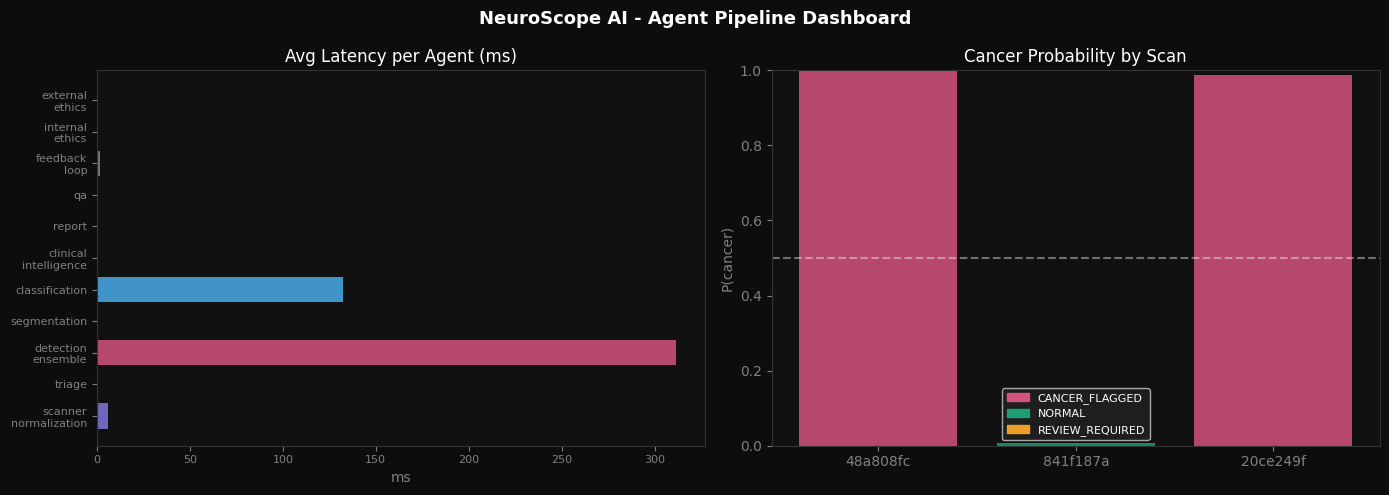


Agent call statistics:
Agent                     Calls  Avg ms    
---------------------------------------------
  scanner_normalization        3        5.7
  triage                       3        0.0
  detection_ensemble           3      311.7
  segmentation                 3        0.1
  classification               3      132.6
  clinical_intelligence        3        0.0
  report                       3        0.1
  qa                           3        0.0
  feedback_loop                3        1.8
  internal_ethics              3        0.0
  external_ethics              3        0.0

Avg total pipeline latency: 465ms


In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb11_agents')

if not all_results:
    print('No results -- run Cell 9 first')
else:
    stats = pipeline.agent_stats()

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('NeuroScope AI - Agent Pipeline Dashboard',
                 color='white', fontsize=13, fontweight='bold')

    # Agent latencies
    agent_names = [s['name'].replace('_', '\n') for s in stats if s['calls'] > 0]
    latencies   = [s['avg_ms'] for s in stats if s['calls'] > 0]
    colors      = ['#7F77DD', '#1D9E75', '#D4537E', '#EF9F27',
                   '#4AACE8', '#E87D4A', '#B87DE8', '#888', '#888', '#888', '#888']

    axes[0].barh(agent_names, latencies,
                 color=colors[:len(agent_names)], alpha=0.85)
    axes[0].set_title('Avg Latency per Agent (ms)', color='white')
    axes[0].set_xlabel('ms', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray', labelsize=8)

    # Pipeline results per test case
    scan_ids  = [r.scan_id for r in all_results]
    probs     = [r.cancer_prob for r in all_results]
    verdicts  = [r.verdict.value for r in all_results]
    v_colors  = {'CANCER_FLAGGED': '#D4537E',
                 'NORMAL'        : '#1D9E75',
                 'REVIEW_REQUIRED': '#EF9F27'}
    bar_cols  = [v_colors.get(v, '#888') for v in verdicts]

    axes[1].bar(scan_ids, probs, color=bar_cols, alpha=0.85)
    axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4)
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Cancer Probability by Scan', color='white')
    axes[1].set_ylabel('P(cancer)', color='gray')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    patches = [mpatches.Patch(color=c, label=v)
               for v, c in v_colors.items()]
    axes[1].legend(handles=patches, facecolor='#222',
                   labelcolor='white', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'pipeline_dashboard.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

    print('\nAgent call statistics:')
    print(f'{"Agent":25s} {"Calls":6s} {"Avg ms":10s}')
    print('-' * 45)
    for s in stats:
        if s['calls'] > 0:
            print(f'  {s["name"]:23s} {s["calls"]:6d} {s["avg_ms"]:10.1f}')

    total_ms = sum(r.total_latency_ms for r in all_results) / len(all_results)
    print(f'\nAvg total pipeline latency: {total_ms:.0f}ms')

---
## Cell 11 - Summary

In [16]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb11_agents')

print('=' * 65)
print('  NOTEBOOK 11 - AGENT ORCHESTRATOR')
print('=' * 65)
print()
print('  All 11 agents implemented:')
agents = [
    ('1',   'TriageAgent',                 'Routes scan, assigns priority 1-5'),
    ('2',   'DetectionEnsembleAgent',      'Binary cancer detection, ONNX ensemble'),
    ('2.5', 'VerificationGate (NB09)',     'Cancer-specific normal thresholds'),
    ('3',   'SegmentationAgent',           'Pixel-level tumor boundary mapping'),
    ('4',   'ClassificationAgent',         'Tumor type, WHO grade, markers'),
    ('5',   'ClinicalIntelligenceAgent',   'Claude API + NCCN rule-based fallback'),
    ('6',   'ReportAgent',                 'Structured radiology report'),
    ('7',   'QAAgent',                     'OOD detection, agreement monitoring'),
    ('8',   'FeedbackLoopAgent',           'Outcome logging, retraining queue'),
    ('9',   'InternalEthicsAgent',         'Demographic bias, hard limits'),
    ('10',  'ExternalEthicsAgent',         'Audit trail, compliance'),
    ('11',  'ScannerNormalizationAgent',   'Stub -- full impl in NB12'),
]
for num, name, desc in agents:
    print(f'  Agent {num:4s}: {name:32s} {desc}')

print()
print('  Pipeline flow:')
print('    11 -> 1 -> 2 -> 2.5 -> 3 -> 4 -> 5 -> 6')
print('    7, 8, 9, 10 run in parallel throughout')
print()
print('  Claude API: enabled if ANTHROPIC_API_KEY set in environment')
print('  Fallback  : NCCN rule-based guidelines (offline mode)')
print()
print('  Next: 12_Scanner_Normalization.ipynb')
print('    - N4 bias field correction (SimpleITK)')
print('    - HU calibration for CT')
print('    - Histogram matching to reference')
print('    - Per-manufacturer profiles')
print('=' * 65)

  NOTEBOOK 11 - AGENT ORCHESTRATOR

  All 11 agents implemented:
  Agent 1   : TriageAgent                      Routes scan, assigns priority 1-5
  Agent 2   : DetectionEnsembleAgent           Binary cancer detection, ONNX ensemble
  Agent 2.5 : VerificationGate (NB09)          Cancer-specific normal thresholds
  Agent 3   : SegmentationAgent                Pixel-level tumor boundary mapping
  Agent 4   : ClassificationAgent              Tumor type, WHO grade, markers
  Agent 5   : ClinicalIntelligenceAgent        Claude API + NCCN rule-based fallback
  Agent 6   : ReportAgent                      Structured radiology report
  Agent 7   : QAAgent                          OOD detection, agreement monitoring
  Agent 8   : FeedbackLoopAgent                Outcome logging, retraining queue
  Agent 9   : InternalEthicsAgent              Demographic bias, hard limits
  Agent 10  : ExternalEthicsAgent              Audit trail, compliance
  Agent 11  : ScannerNormalizationAgent        Stub -- 